# Red Neuronal

Resolver el problema de supervivencia del Titanic con un perceptron multicapa usando el dataset preprocesado.

In [ ]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Quitamos warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

## 1. Carga del dataset

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Limpieza y preprocesamiento

In [3]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked'], drop_first=True)
df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,0,True,False,True
1,1,1,38.0,1,0,71.2833,2,0,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,True
3,1,1,35.0,1,0,53.1000,2,0,False,False,True
4,0,3,35.0,0,0,8.0500,1,1,True,False,True


## 3. Separar variables y dividir

In [4]:
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)   

## 4. Escalado de variables

Aplicamos `StandardScaler` (media 0 y desviacion 1). 
Hacemos `fit_transform` solo en train y luego `transform` en test, para no filtrar informacion del conjunto de test al modelo.
Porque el conjunto de test simula datos que aún no hemos visto. Si calculáramos la media/desviación con el test (fit_transform(X_test)), estaríamos espiando información del futuro y metiéndosela al modelo por la puerta de atrás.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Breve explicacion de la red neuronal

Un **perceptrón multicapa** es una red formada por una capa de entrada, una o varias capas ocultas y una capa de salida. Cada neurona calcula una suma ponderada de sus entradas y le aplica una funcion de activacion (por ejemplo `relu` o `tanh`).

La red aprende ajustando los pesos w y los bias b mediante:

1. **Feedforward**: calcula la prediccion propagando las entradas hacia delante.
2. **Backpropagation**: compara la prediccion con la respuesta correcta y propaga el error hacia atras.
3. **Descenso de gradiente**: actualiza los pesos en la direccion que reduce el error.

Vamos a usar `MLPClassifier`.

## 6. Entrenamiento y evaluacion

In [7]:
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    max_iter=500,
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Clasification report:')
print(classification_report(y_test, y_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8426966292134831
Clasification report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       110
           1       0.87      0.69      0.77        68

    accuracy                           0.84       178
   macro avg       0.85      0.81      0.83       178
weighted avg       0.85      0.84      0.84       178

Confusion matrix:
[[103   7]
 [ 21  47]]


## 7. Curva de perdida

`MLPClassifier` guarda en `loss_curve_` el valor de la funcion de perdida en cada iteracion del entrenamiento. Solo esta disponible cuando el solver entrena por epocas (`adam` o `sgd`); con `lbfgs` no se rellena porque optimiza en bloque.

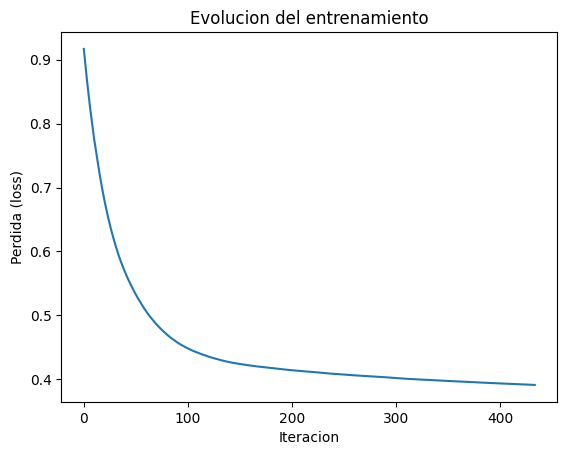

In [8]:
if hasattr(model, 'loss_curve_'):
    plt.plot(model.loss_curve_)
    plt.xlabel('Iteracion')
    plt.ylabel('Perdida (loss)')
    plt.title('Evolucion del entrenamiento')
    plt.show()
else:
    print(f"El solver '{model.solver}' no expone loss_curve_.")

## 8. Busqueda simple de hiperparametros

Probamos manualmente varias configuraciones y nos quedamos con la de mayor accuracy.

In [9]:
configs = [
    {'hidden_layer_sizes': (8,),    'activation': 'relu'},
    {'hidden_layer_sizes': (10,),   'activation': 'relu'},
    {'hidden_layer_sizes': (10, 5), 'activation': 'relu'},
    {'hidden_layer_sizes': (10,),   'activation': 'tanh'},
]

best_score = 0.0
best_cfg = None

for cfg in configs:
    temp_model = MLPClassifier(**cfg, max_iter=500, random_state=42)
    temp_model.fit(X_train_scaled, y_train)
    score = temp_model.score(X_test_scaled, y_test)
    print(f'hidden_layer_sizes={cfg["hidden_layer_sizes"]}, activation={cfg["activation"]} -> accuracy={score:.4f}')
    if score > best_score:
        best_score = score
        best_cfg = cfg

print('\nMejor configuracion:', best_cfg)
print('Mejor accuracy:', best_score)

hidden_layer_sizes=(8,), activation=relu -> accuracy=0.8258


hidden_layer_sizes=(10,), activation=relu -> accuracy=0.8427


hidden_layer_sizes=(10, 5), activation=relu -> accuracy=0.8315


hidden_layer_sizes=(10,), activation=tanh -> accuracy=0.8258

Mejor configuracion: {'hidden_layer_sizes': (10,), 'activation': 'relu'}
Mejor accuracy: 0.8426966292134831


## 9. Conclusion y explicacion de resultados

In [10]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

tn, fp, fn, tp = cm.ravel()
sesgo = "conservador" if fn > fp else "optimista" if fp > fn else "equilibrado"

print("Conclusion y explicacion (resumen automatico)")
print(f"- Accuracy: {acc:.3f}")
print(f"- Clase 0 (no sobrevive): precision={report['0']['precision']:.3f}, recall={report['0']['recall']:.3f}")
print(f"- Clase 1 (sobrevive): precision={report['1']['precision']:.3f}, recall={report['1']['recall']:.3f}")
print(f"- Matriz de confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp} -> sesgo {sesgo}")
print(f"- Mejor configuracion: {best_cfg} con accuracy {best_score:.3f}")
print(f"- Numero de iteraciones realizadas: {model.n_iter_}")

Conclusion y explicacion (resumen automatico)
- Accuracy: 0.843
- Clase 0 (no sobrevive): precision=0.831, recall=0.936
- Clase 1 (sobrevive): precision=0.870, recall=0.691
- Matriz de confusion: TN=103, FP=7, FN=21, TP=47 -> sesgo conservador
- Mejor configuracion: {'hidden_layer_sizes': (10,), 'activation': 'relu'} con accuracy 0.843
- Numero de iteraciones realizadas: 434
